Đang tải dữ liệu CIFAR10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước dữ liệu huấn luyện: (50000, 32, 32, 3)
Kích thước dữ liệu kiểm tra: (10000, 32, 32, 3)
Kích thước ảnh đầu vào: (32, 32, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện Autoencoder...
Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0255
Epoch 1: val_loss improved from inf to 0.01132, saving model to logs/autoencoder_cifar10_best.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - loss: 0.0255 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 2/100
387/391 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0100
Epoch 2: val_loss improved from 0.01132 to 0.00833, saving model to logs/autoencoder_cifar10_best.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0100 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 3/100
387/391 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0082
Epoch 3: val_loss improved from 0.00833 to 0.00769, saving model to logs/autoencoder_cifar10_best.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0082 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 4/100
387/391 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072
Epoch 4: val_loss improved from 0.00769 to 0.00669, saving model to logs/autoenco

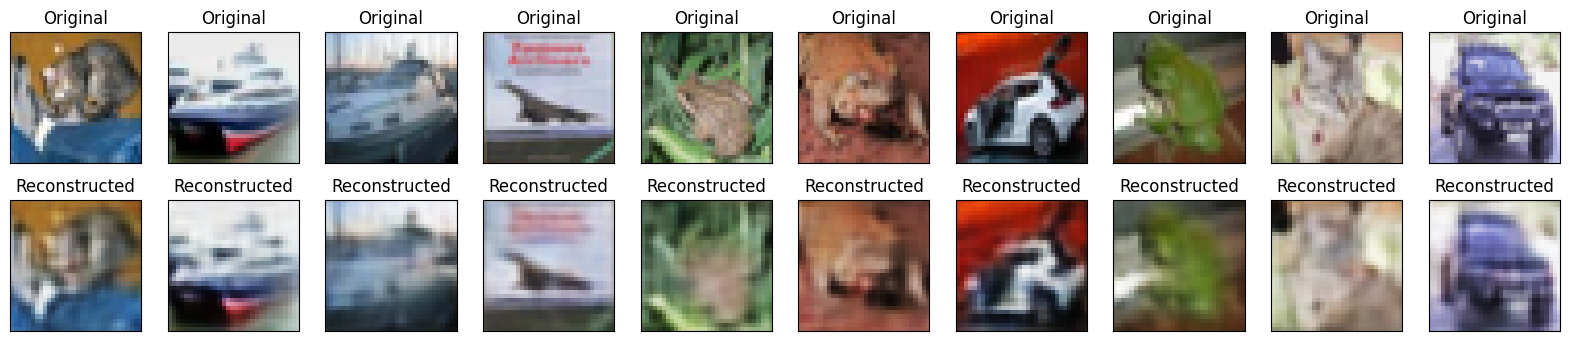

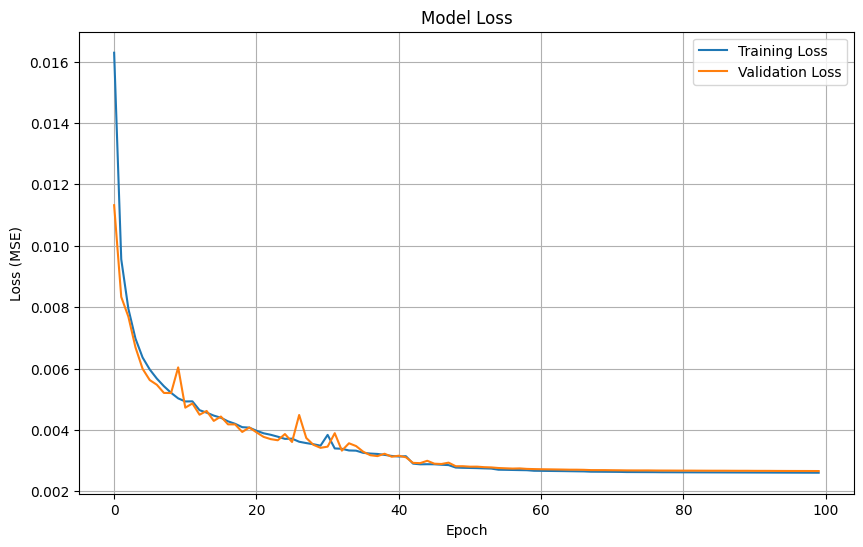

Chương trình đã chạy xong.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Tải và chuẩn bị dữ liệu CIFAR10
print("Đang tải dữ liệu CIFAR10...")
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu về khoảng [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape dữ liệu để phù hợp với Conv2D (samples, height, width, channels)
# CIFAR10 có ảnh 32x32x3
input_shape = x_train.shape[1:]

print(f"Kích thước dữ liệu huấn luyện: {x_train.shape}")
print(f"Kích thước dữ liệu kiểm tra: {x_test.shape}")
print(f"Kích thước ảnh đầu vào: {input_shape}")

# 2. Xây dựng kiến trúc Autoencoder
# Encoder
input_img = Input(shape=input_shape)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x) # 16x16x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x) # 8x8x64
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x) # 4x4x128

# Decoder
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x) # 8x8x128
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # 16x16x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # 32x32x32

# Output layer: Sử dụng Conv2D với số filter bằng số kênh của ảnh gốc và activation sigmoid để tái tạo giá trị pixel [0, 1]
decoded = Conv2D(input_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)

# Khởi tạo mô hình Autoencoder
autoencoder = Model(input_img, decoded)

# 3. Biên dịch mô hình
autoencoder.compile(optimizer='adam', loss='mse') # Sử dụng 'mse' (Mean Squared Error) cho bài toán tái tạo ảnh

# In tóm tắt kiến trúc mô hình
autoencoder.summary()

# 4. Cấu hình Callbacks cho quá trình huấn luyện tối ưu
# Colab tips: Sử dụng EarlyStopping để dừng huấn luyện khi loss không cải thiện
# ModelCheckpoint để lưu lại trọng số tốt nhất
# ReduceLROnPlateau để giảm learning rate khi loss bị kẹt
log_dir = "logs"
checkpoint_filepath = os.path.join(log_dir, 'autoencoder_cifar10_best.keras')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_filepath, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
]

# 5. Huấn luyện mô hình
print("Bắt đầu huấn luyện Autoencoder...")
history = autoencoder.fit(x_train, x_train,
                          epochs=100, # Có thể tăng/giảm số epoch tùy vào sự hội tụ
                          batch_size=128, # Tăng batch_size để tận dụng GPU tốt hơn
                          shuffle=True,
                          validation_data=(x_test, x_test),
                          callbacks=callbacks)

# 6. Đánh giá và hiển thị kết quả
print("Hoàn thành huấn luyện.")

# Tải lại trọng số tốt nhất đã lưu
autoencoder.load_weights(checkpoint_filepath)

# Dự đoán trên tập kiểm tra
decoded_imgs = autoencoder.predict(x_test)

# Hiển thị ảnh gốc và ảnh được tái tạo
n = 10  # Số lượng ảnh để hiển thị
plt.figure(figsize=(20, 4))
for i in range(n):
    # Ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Ảnh được tái tạo
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Hiển thị biểu đồ loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

print("Chương trình đã chạy xong.")